In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import qstudy as qs
import statsmodels.api as sm
import matplotlib.pyplot as plt
from qstudy import Study

In [2]:
TICKERS = [
    "AAPL", "MSFT", "AMZN", "NVDA", "GOOGL", "META", "JPM", "XOM", "JNJ", "PG",
    "HD", "COST", "AVGO", "WMT", "MRK", "CVX", "ABBV", "PEP", "KO", "BAC",
]
FACTOR_TICKERS = ["SPY", "XLK", "XLF"]
START = "2020-01-01"
END = "2025-01-01"
RETURN_ATOL = 1e-10
EQUITY_ATOL = 1e-10

In [3]:
def residualize_manual(returns: pd.DataFrame, factor_returns: pd.DataFrame) -> pd.DataFrame:
    common_index = returns.index.intersection(factor_returns.index)
    r = returns.loc[common_index]
    f = sm.add_constant(factor_returns.loc[common_index])

    residuals = pd.DataFrame(index=common_index, columns=r.columns, dtype=float)
    for ticker in r.columns:
        y = r[ticker].dropna()
        x = f.loc[y.index]
        model = sm.OLS(y, x).fit()
        residuals.loc[y.index, ticker] = model.resid

    return residuals


def apply_vol_filter(signal: pd.DataFrame, returns: pd.DataFrame, vol_window: int, quantile: float) -> pd.DataFrame:
    realized_vol = returns.rolling(vol_window).std()
    vol_thresh = realized_vol.quantile(quantile, axis=1)
    mask = realized_vol.lt(vol_thresh, axis=0)
    return signal.where(mask)


def apply_volume_zscore_filter(
    signal: pd.DataFrame,
    volume: pd.DataFrame,
    window: int,
    min_zscore_quantile: float,
) -> pd.DataFrame:
    vol_mean = volume.rolling(window).mean()
    vol_std = volume.rolling(window).std()
    vol_z = (volume - vol_mean) / vol_std
    thresh = vol_z.quantile(min_zscore_quantile, axis=1)
    mask = vol_z.ge(thresh, axis=0)
    return signal.where(mask)


def liquidity_mask(close: pd.DataFrame, volume: pd.DataFrame, top_n: int, window: int) -> pd.DataFrame:
    dollar_vol = (close * volume).dropna(axis=1)
    avg_dollar_vol = dollar_vol.rolling(window).mean()
    rank = avg_dollar_vol.rank(axis=1, ascending=False)
    return rank <= top_n


def build_long_short_positions_manual(signal: pd.DataFrame, n_long: int, n_short: int) -> pd.DataFrame:
    signal_rank = signal.rank(axis=1, ascending=False, na_option="bottom")
    n_tradeable = signal.count(axis=1)

    long_mask = signal_rank <= n_long
    short_cutoff = n_tradeable - (n_short - 1)
    short_mask = signal_rank.ge(short_cutoff.values[:, None]) & signal.notna()

    positions = long_mask.astype(float) - short_mask.astype(float)
    abs_sum = positions.abs().sum(axis=1).replace(0.0, float("nan"))
    return positions.div(abs_sum, axis=0)


def run_manual_pipeline(universe, factors) -> tuple[pd.Series, pd.Series]:
    returns = universe.returns
    close = universe.close
    volume = universe.volume

    residuals = residualize_manual(returns, factors.returns)

    signal = -residuals.rolling(5).mean()
    signal = signal.sub(signal.mean(axis=1), axis=0)
    signal = apply_vol_filter(signal, residuals, vol_window=5, quantile=0.6)
    signal = apply_volume_zscore_filter(signal, volume, window=20, min_zscore_quantile=0.7)

    tradeable = liquidity_mask(close, volume, top_n=15, window=30)
    signal = signal.where(tradeable)
    ret_filtered = returns.where(tradeable)

    positions = build_long_short_positions_manual(signal, n_long=3, n_short=3)

    raw_port_ret = (positions.shift(1) * ret_filtered).sum(axis=1)
    equity = (1 + raw_port_ret).cumprod()
    scale = pd.Series(np.where(equity > equity.rolling(10).mean(), 1.0, 0.25), index=equity.index)
    scaled_positions = positions.mul(scale.shift(1).fillna(1.0), axis=0)

    port_ret = (scaled_positions.shift(1) * ret_filtered).sum(axis=1)
    equity_curve = (1 + port_ret).cumprod()
    return port_ret, equity_curve

In [4]:
# qstudy implementation.
#
# The key abstraction is the Study cache. During Study.run(), qstudy builds
# a cache dict that holds the aligned market data and intermediate pipeline state.
# Common keys include:
#   cache["returns"]            -> raw universe returns
#   cache["volume"]             -> raw universe volume
#   cache["close"]              -> raw universe close prices
#   cache["residual_returns"]   -> populated by .residualize_returns()
#   cache["signal"]             -> current signal after each filter/transform step
#   cache["positions"]          -> final post-scaler positions
#   cache["portfolio_returns"]  -> final backtest return series
#   cache["_tradeable_mask"]    -> boolean eligibility mask built by tradeable constraints
#
# Your custom callables don't mutate the Study object directly. They receive a shallow
# copy of the cache so they can read the current state and return a transformed result.
# qstudy handles the orchestration and stores the outputs back into the Study state.
def residual_mr_signal(**cache):
    # You can define the alpha formula
    # Because .residualize_returns() was called earlier in the chain, qstudy has already populated cache["residual_returns"].
    # No .shift(1). The engine.run() applies the execution lag
    return -cache["residual_returns"].rolling(5).mean()


def demean_signal(signal, **cache):
    return signal.sub(signal.mean(axis=1), axis=0)


def equity_curve_regime_scale(positions, **cache):
    # Custom position scaler. qstudy has already built the raw long/short positions.
    # This function can inspect both the positions and the cache, then return adjusted
    # positions. It runs before the final engine call.
    returns = cache["returns"]
    tradeable = cache.get("_tradeable_mask")
    # .add_tradeable_constraint(...) stores the combined boolean mask in
    # cache["_tradeable_mask"]. We reuse it here so the regime logic only sees returns
    # from assets that were eligible at that point in the pipeline.
    if tradeable is not None:
        returns = returns.where(tradeable)

    # When a custom scaler internally recomputes a PnL stream, it must use lagged
    # positions to match qstudy.study.engine.run(). The execution lag lives in the engine,
    # not in the signal function.
    raw_port_ret = (positions.shift(1) * returns).sum(axis=1)
    equity = (1 + raw_port_ret).cumprod()
    scale = pd.Series(np.where(equity > equity.rolling(10).mean(), 1.0, 0.25), index=equity.index)
    return positions.mul(scale.shift(1).fillna(1.0), axis=0)


def run_qstudy_pipeline(universe, factors) -> tuple[pd.Series, pd.Series]:
    # Built-in pieces used below:
    #   .residualize_returns()              -> fills cache["residual_returns"]
    #   .add_vol_filter(...)                -> built-in signal filter
    #   .add_volume_zscore_filter(...)      -> built-in signal filter
    #   .add_tradeable_constraint(...)      -> pass built-in tradeable universe constraints such as qs.liquidity(...)
    #   .build_long_short(...)              -> built-in position builder
    #   .scale_risk(custom_fn)              -> hook for custom post position scaling logic
    #   .run()                              -> executes the full pipeline
    #
    # qstudy owns the plumbing. You supply the research-specific callables where you need custom behavior.
    study = (
        Study(universe=universe, factors=factors, name="manual_vs_qstudy", verbose=False)
        .residualize_returns()
        .base_signal(residual_mr_signal)
        .transform_signal(demean_signal)
        .add_vol_filter(vol_window=5, quantile=0.6)
        .add_volume_zscore_filter(window=20, min_zscore_quantile=0.7)
        .add_tradeable_constraint(qs.liquidity(top_n=15, window=30))
        .build_long_short(n_long=3, n_short=3)
        .scale_risk(equity_curve_regime_scale)
        .run()
    )

    port_ret = study.cache["portfolio_returns"]
    equity_curve = (1 + port_ret).cumprod()
    return port_ret, equity_curve


In [5]:
print("Downloading universe data once via qstudy...")
universe = qs.download(TICKERS, start=START, end=END)

print("Downloading factor data once via qstudy...")
factors = qs.download(FACTOR_TICKERS, start=START, end=END)

print(
    f"Universe tickers: {len(universe.tickers)} | "
    f"Dates: {universe.returns.index[0].date()} -> {universe.returns.index[-1].date()}"
)

Universe tickers: 20 | Dates: 2020-01-02 -> 2024-12-31


In [6]:
manual_returns, manual_equity = run_manual_pipeline(universe, factors)
qstudy_returns, qstudy_equity = run_qstudy_pipeline(universe, factors)

common_index = manual_returns.index.intersection(qstudy_returns.index)
manual_returns = manual_returns.reindex(common_index)
qstudy_returns = qstudy_returns.reindex(common_index)
manual_equity = manual_equity.reindex(common_index)
qstudy_equity = qstudy_equity.reindex(common_index)

Using factors for residuals...


,manual_equity,qstudy_equity
Date,,
2024-12-24,1.027897,1.027897
2024-12-26,1.027897,1.027897
2024-12-27,1.027897,1.027897
2024-12-30,1.027181,1.027181
2024-12-31,1.026145,1.026145


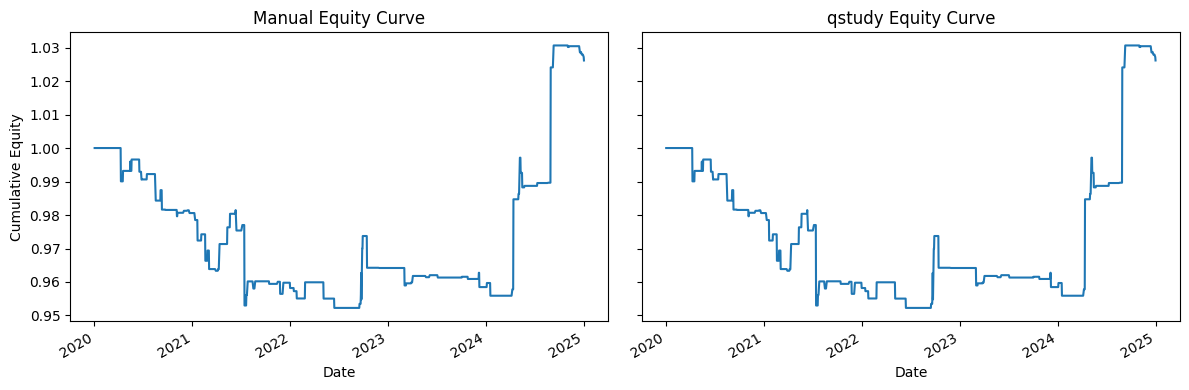

In [7]:
equity_curves = pd.DataFrame(
    {
        "manual_equity": manual_equity,
        "qstudy_equity": qstudy_equity,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
equity_curves[["manual_equity"]].plot(ax=axes[0], legend=False, title="Manual Equity Curve")
equity_curves[["qstudy_equity"]].plot(ax=axes[1], legend=False, title="qstudy Equity Curve")
axes[0].set_ylabel("Cumulative Equity")
axes[1].set_ylabel("")
plt.tight_layout()
equity_curves.tail()